# The bipolar north fold (on tripolar grids)

Global ocean grids like MOM6, NEMO, and Oceananigans are **tripolar** — the
South Pole plus two poles displaced over Arctic land — and their northern edge
folds onto itself along the **bipolar seam** joining the two northern poles. To
evaluate `interp`/`diff`/`derivative` across that edge, xgcm pads a northern
**halo** by reflecting the interior about the nearest pole (sign-flipping vector
components). If that reconstruction is correct, a physically smooth field stays
**smooth across the seam**.

Rather than map the Arctic (where a polar projection distorts the seam, land
masks it with a blank line, and model noise muddies the picture), we look at the
fold **directly in logical grid-index space** — x-index across, y-index up. The
seam is then just a horizontal line, and the fold's action is plain to see:

* the **halo is the interior reflected about the poles** — so any structure at
  the seam is the model's own field mirrored, *not* a fold artifact;
* the naive `extend` boundary instead **smears the edge value** upward;
* walking a column **across** the seam, the fold **continues** the real field
  while naive **flatlines**.

We show this for **three models** (real surface velocities `u`,`v`): MOM6
(GFDL-CM4) and NEMO (IPSL-CM6A-LR) use a `"corner"` fold pivot, Oceananigans a
`"u"` pivot.

> **Dependencies** — the MOM6/NEMO sections read CMIP6 from the Pangeo cloud
> (`zarr`, `gcsfs`); the Oceananigans section downloads its snapshot from Zenodo
> (`pooch`). All three are already in `environment.yml`.

In [1]:
import numpy as np
import xarray as xr
import pooch

from xgcm import Grid
from xgcm.padding import pad

# Figure-drawing only; every xgcm call in this notebook stays inline and visible.
import tripolar_plots as tp

so = {"storage_options": {"token": "anon"}}

# Oceananigans/ClimaOcean tripolar surface snapshot, hosted on Zenodo.
# v1 = model-day 10 (DOI 10.5281/zenodo.20950679). To switch to the day-365 v2
# later, bump just these two lines to the new version's URL + md5 hash.
OCEANANIGANS_URL = "https://zenodo.org/records/20950679/files/oceananigans_tripolar.nc"
OCEANANIGANS_MD5 = "md5:5460639792880fa76826430d9290d87a"

## Helpers

`package` puts a model's `u`,`v` on a common staggered index grid and masks land
(cells whose velocity is missing, or zero where zeros dominate — e.g. the
Oceananigans immersed boundary), so land never leaks through `interp`/`diff`.
The diagnostics each cross the fold through a different operation: `speed_centre`
tests `interp` (interpolating `v` to the cell centre across the seam), and
`divergence` tests `diff` (its `∂v/∂y` term crosses the seam).

In [2]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label,
                ny=ny, nx=nx)


def _grid(coords, edge, ybc):
    '''A Grid on this model's index coords: the seam axis X wraps, and the fold
    axis Y carries either the north-fold spec or a naive boundary (for contrast).'''
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                padding={"X": "periodic", "Y": ybc},
                # these are bare index coordinates, with no Comodo/SGRID attributes
                # for xgcm to parse, so we describe the positions ourselves above
                autoparse_metadata=False)


def speed_centre(m):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    uc = g.interp(m["u"], "X")
    vc = g.interp({"Y": m["v"]}, "Y")
    return np.hypot(uc, vc)


def divergence(m):
    '''Horizontal divergence du/dx + dv/dy (per grid cell) at the cell centre;
    the dv/dy diff crosses the fold, so this exercises `diff` (and the vector
    fold of v) across the seam. Unlike vorticity, divergence is a TRUE SCALAR —
    invariant under the 180° fold — so it is continuous across the seam and its
    halo is simply the mirrored interior, with no sign subtlety.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]})
    dudx = g.diff(m["u"], "X")  # X is periodic (the seam axis); let it wrap
    dvdy = g.diff({"Y": m["v"]}, "Y")
    return dudx + dvdy

## Reading the halo directly

The figures below all show the same thing: a zoom of the topmost grid rows in
logical index space — the interior just below the seam line, and `K` halo rows
above it.

To build those halo rows we step *underneath* `interp`/`diff` and call
`xgcm.padding.pad` directly. That is not how you would normally use xgcm — the
operators above already pad for you — but it is what makes the fold visible:
`pad` hands back exactly the halo the operators use internally, so we can plot it
and compare a fold halo against a naive one side by side.

The drawing itself lives in `tripolar_plots.py`, imported as `tp`, so the
matplotlib bookkeeping stays out of the way of the xgcm calls.

In [3]:
def _pad_scalar(S, m, K, mode):
    '''K halo rows above a centre scalar field: fold (mirror) or extend (smear).'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if mode == "fold" else "extend")
    return np.asarray(pad(S, g, padding_width={"Y": (0, K)}).values)


def _pad_v(m, K, mode, vector):
    '''K halo rows above the v component. vector=True folds it as a vector (the
    180° pivot flips its sign); vector=False folds it as a plain scalar. v lives
    at (y_f, x_c); for the vector case u is the other (X) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"Y": m["v"]}, g, padding_width={"Y": (0, K)}, other_component={"X": m["u"]})
    else:
        out = pad(m["v"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


def _pad_u(m, K, mode, vector):
    '''K halo rows above the u component (zonal). vector=True folds it as a
    vector (the 180° pivot flips its sign); vector=False as a plain scalar. u
    lives at (y_c, x_f); for the vector case v is the other (Y) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    if vector:
        out = pad({"X": m["u"]}, g, padding_width={"Y": (0, K)}, other_component={"Y": m["v"]})
    else:
        out = pad(m["u"], g, padding_width={"Y": (0, K)})
    return np.asarray(out.values)


def fill_seam_vrow(m):
    '''Reconstruct the redundant top row of the meridional velocity ``v``.

    On a tripolar F-fold the top ``v`` faces lie on the seam and come in fold
    pairs ``v(i) = -v(mirror(i))``; the CMIP6 NEMO/MOM6 products keep one half of
    that row and mask the other (the redundant duplicate). xgcm's fold fills
    *halos* from the interior, not interior gaps, so we rebuild this seam row
    here from its fold partner. Without it, interpolating ``v`` to the cell
    centre (e.g. for surface speed) would leave a blank band at the seam. Only
    masked cells whose fold partner is present are filled (a no-op for fields
    that are already complete, e.g. the Oceananigans simulation output).'''
    v = np.asarray(m["v"].values).copy()
    nx = v.shape[1]
    mirror = (-np.arange(nx) - 1) % nx          # seam reflection (seam axis = edge)
    top = v[-1]
    fill = ~np.isfinite(top) & np.isfinite(top[mirror])
    top[fill] = -top[mirror][fill]              # v flips sign across the fold
    m["v"] = m["v"].copy(data=v)

## Load the three models

CMIP6 surface velocities for MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from the
Pangeo cloud, plus a realistic 1° ClimaOcean/Oceananigans surface snapshot
downloaded from Zenodo ([10.5281/zenodo.20950679](https://doi.org/10.5281/zenodo.20950679)).
CMIP6 masks its redundant northern row, so we drop it before folding.

One subtlety of the CMIP6 tripolar output: the **top row of the meridional
velocity `v`** sits on the fold seam, where its faces are fold duplicates
(`v(i) = -v(mirror(i))`), and the product masks one half of that row. xgcm's fold
fills *halos*, not interior gaps, so `fill_seam_vrow` rebuilds that seam row from
its fold partner at load time — otherwise interpolating `v` to cell centres
(for surface speed) would leave a blank band right at the seam. The fold method
itself doesn't depend on this; it only ever reflects fully-defined interior
rows. (It's a no-op for the Oceananigans field, which is complete.)

In [4]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    base = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
            f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(base.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    path = pooch.retrieve(url=OCEANANIGANS_URL, known_hash=OCEANANIGANS_MD5,
                          fname="oceananigans_tripolar.nc")
    o = xr.open_dataset(path)
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]
for m in models:          # F-pivot models ship the redundant top v-row masked; rebuild it
    if m["fold"] in ("corner", "f"):
        fill_seam_vrow(m)

# Everything the figures draw is computed here, with xgcm, so the operators stay
# in plain sight: the two diagnostics, then their halos filled both ways.
K = 6
for m in models:
    m["speed"] = speed_centre(m)                        # `interp` crosses the fold
    m["div"] = divergence(m)                            # `diff` crosses the fold
    for name in ("speed", "div"):
        m[f"{name}_fold"] = _pad_scalar(m[name], m, K, "fold")
        m[f"{name}_naive"] = _pad_scalar(m[name], m, K, "extend")
    for comp, pad_fn in (("v", _pad_v), ("u", _pad_u)):
        m[f"{comp}_scalarfold"] = pad_fn(m, K, "fold", False)
        m[f"{comp}_vectorfold"] = pad_fn(m, K, "fold", True)

tp.attach_windows(models, K=K)   # one shared open-water window per model, for every figure below

/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(
/Users/henrifdrake/code/xgcm/.claude/worktrees/agent-ab8dea27f966b6233/xgcm/grid.py:463: UserWarning: The north-fold (tripolar) boundary condition is experimental. It

### First, just look at the arrays

Before any fold machinery, here is each model's surface speed exactly as it sits
in memory — y-index up, x-index across, no projection. The red line marks the top
edge of the array. On a tripolar grid that edge is not a wall: it is glued to
*itself*, reversed about the two Arctic poles. Everything that follows is about
what belongs immediately above that line.

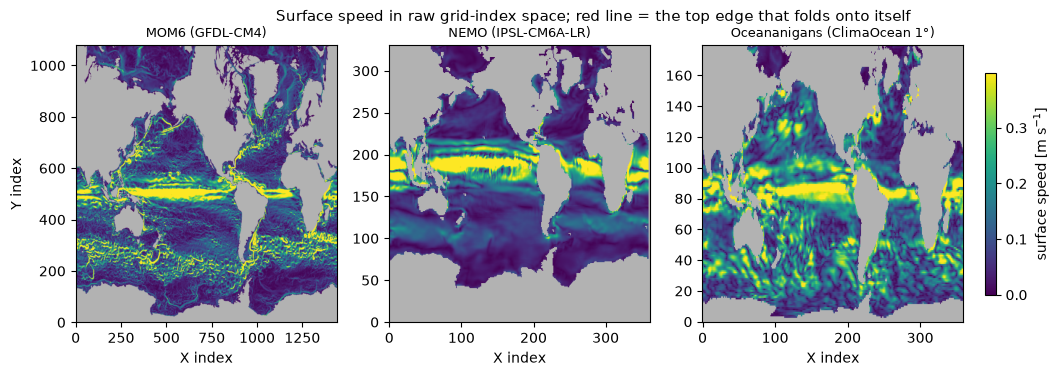

In [5]:
tp.index_space_overview(models)

## `interp` across the fold — what fills the halo

Surface speed at tracer (centre) points near the seam, zoomed to a patch of open
water so each grid cell is visible. The **interior** (below the black line) is
the real field. The **fold halo** above the line is the genuine cross-seam
neighbourhood (the interior reflected about the pole) — real, structured data
that continues the field. The **naive** `extend` halo instead copies the edge
value straight up, so each column is a constant **vertical streak**. The
**difference** is zero in the interior and nonzero only in the halo: the fold
changes nothing inside, it only supplies a physically correct neighbourhood
beyond the edge. (That the continuation is *smooth* is shown by the transect
below. The NEMO panel is gap-free here because we rebuilt its masked seam `v`
row at load time — see above.)

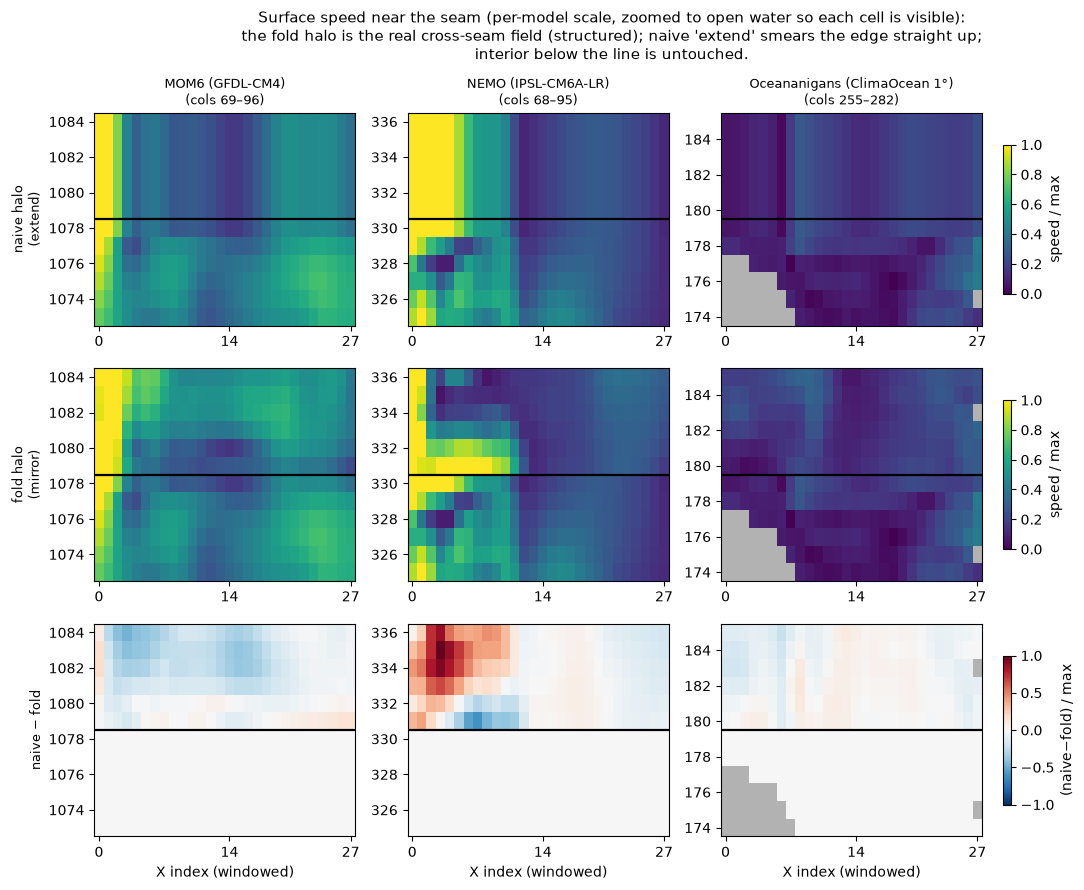

In [6]:
tp.halo_strip(models, "speed_naive", "speed_fold", K=K,
              cbar_label="speed / max",
              suptitle="Surface speed near the seam (per-model scale, zoomed to open water so each "
                       "cell is visible):\nthe fold halo is the real cross-seam field (structured); "
                       "naive 'extend' smears the edge straight up;\ninterior below the line is "
                       "untouched.")

## Vector components flip sign across the seam

Folding the grid rotates the local axes by 180°, so **both** velocity components
reverse sign across the fold while a scalar does not. To see it cell-by-cell we
fold each component two ways in the same window: as a plain **scalar** and **as
a vector** (passing the other component via `other_component`). For `v`
(meridional) and `u` (zonal) alike, below the seam line the two folds are
identical; in the **halo** above the line they are the same magnitude but
**opposite sign** — the colours invert. That sign flip, on both components, is
the signature of correct vector folding.

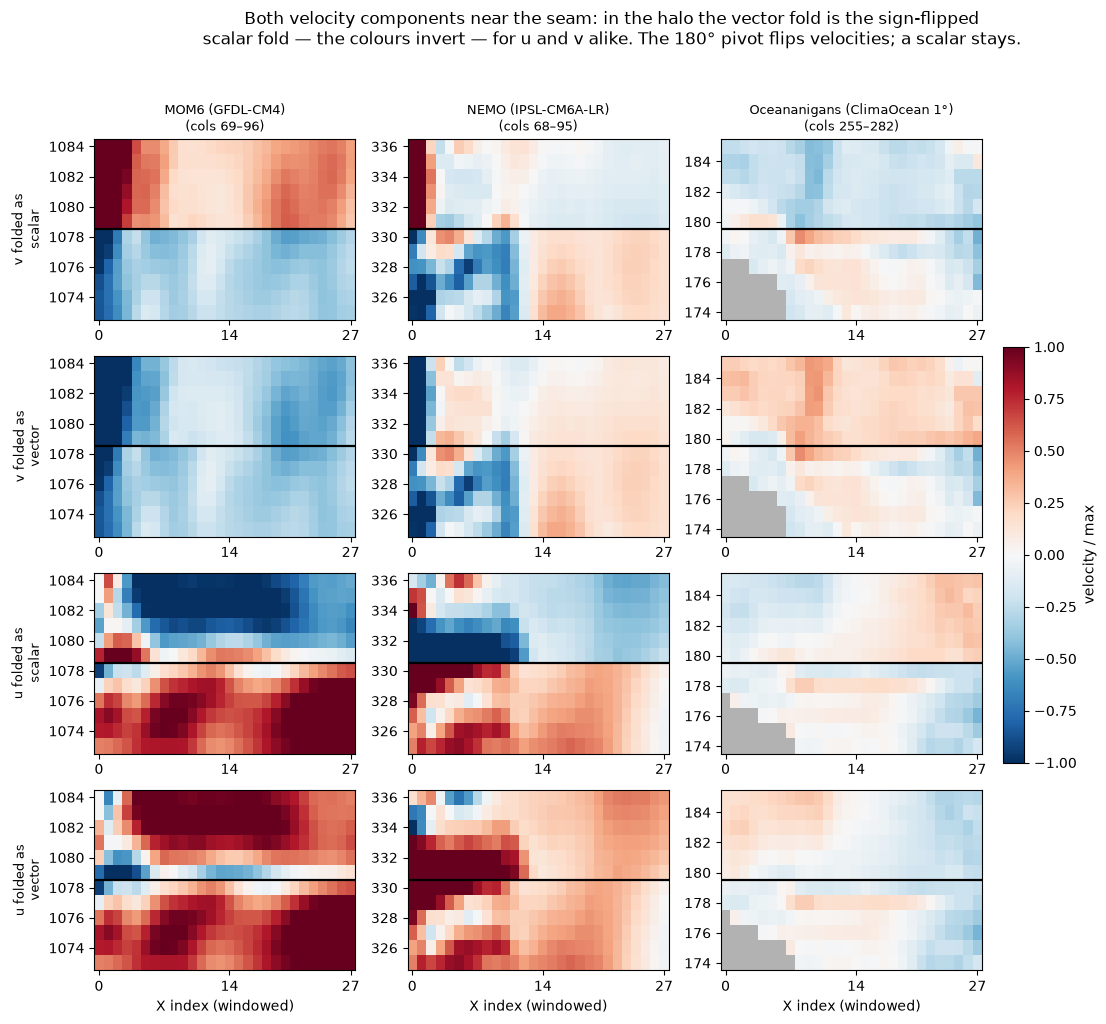

In [7]:
tp.component_strip(models, K=K)

## Continuity across the seam — a transect

The cleanest correctness check: follow a few ocean columns from the interior,
across the seam (dotted), into the halo. The **fold** continues the real,
varying field (the seam partner is a genuine physical neighbour); the **naive**
boundary flatlines at the edge value. Where a column's halo runs into Arctic
land the line simply stops — there is no data there, but that is land, not a
fold error.

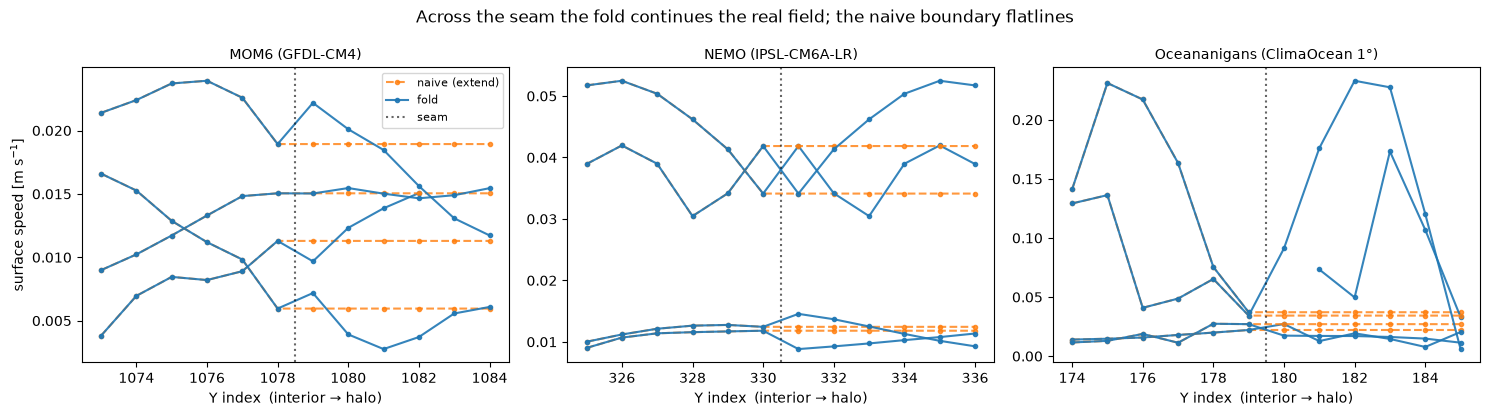

In [8]:
tp.seam_transect(models, K=K)

## `diff` across the fold — horizontal divergence $\nabla\!\cdot\mathbf{u}$

The same holds for differencing. We use the horizontal divergence
$\nabla\!\cdot\mathbf{u}=\partial u/\partial x+\partial v/\partial y$ at the cell
**centre**, whose $\partial v/\partial y$ term crosses the seam (and needs the
vector fold of `v`), so computing it exercises `diff` across the fold. We choose
divergence deliberately: it is a **true scalar** (invariant under the fold's
180° rotation), so — exactly like surface speed, and *unlike* relative vorticity
$\zeta=\partial v/\partial x-\partial u/\partial y$, which is a sign-flipping
pseudoscalar evaluated at the awkward cell corner — its halo is simply the
mirrored interior, with no sign subtlety and no registration ambiguity. Shown the
same way as the speed strip: the **fold halo** continues the field smoothly
across the seam, the **naive** `extend` halo smears the edge, and their
**difference** is zero in the interior and nonzero only in the halo — the two
boundaries differ only above the seam, leaving the real field below untouched.

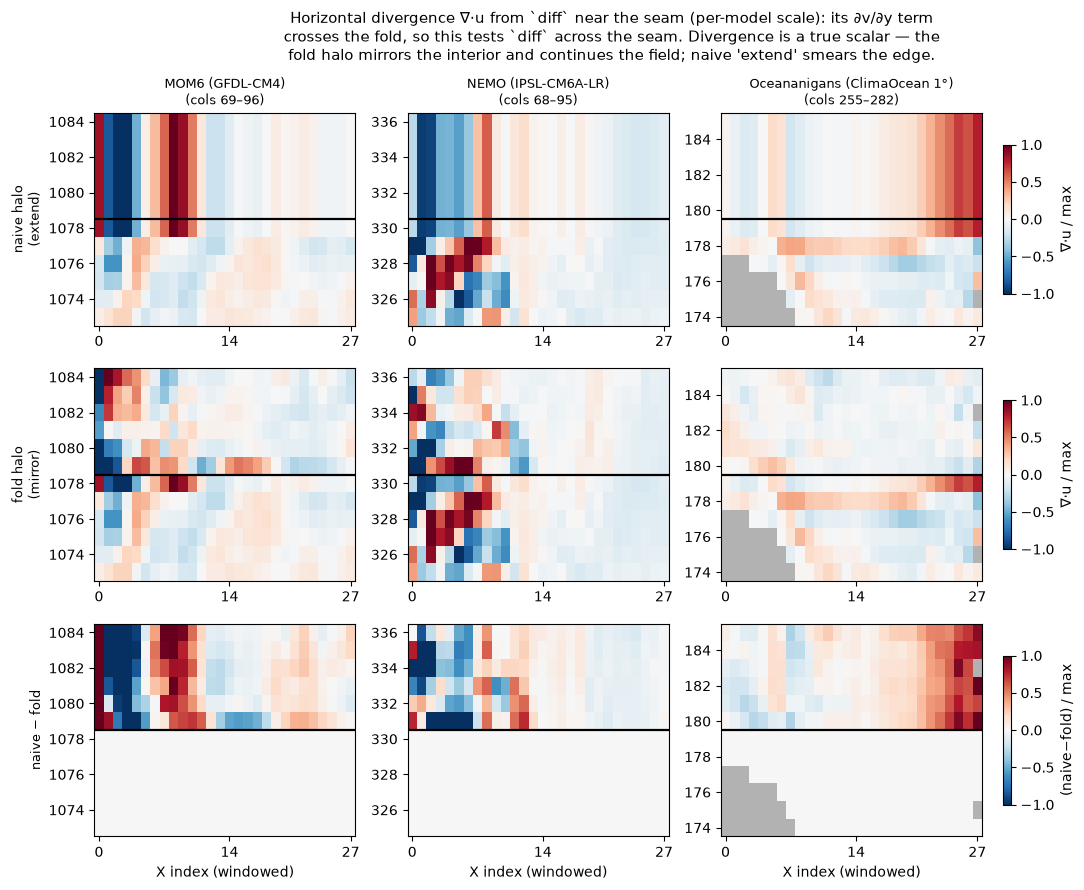

In [9]:
tp.halo_strip(models, "div_naive", "div_fold", K=K, signed=True,
              cbar_label="∇·u / max",
              suptitle="Horizontal divergence ∇·u from `diff` near the seam (per-model scale): its "
                       "∂v/∂y term\ncrosses the fold, so this tests `diff` across the seam. "
                       "Divergence is a true scalar — the\nfold halo mirrors the interior and "
                       "continues the field; naive 'extend' smears the edge.")

## Takeaway

Seen directly in grid-index space, the bipolar north fold is transparent: xgcm
fills the northern halo with the interior **reflected about the poles**,
sign-flipping vector components. So

* a smooth scalar (surface speed) **continues across the seam** — the fold halo
  is the mirrored interior, the transect stays continuous — while the naive
  `extend` boundary smears the edge and flatlines;
* a velocity component additionally **reverses sign** across the seam, the
  signature of the 180° pivot;
* a `diff`-based true scalar (the horizontal divergence) **continues across the
  seam** just like an interpolated scalar — corrected **exactly along the seam
  row** and left untouched elsewhere — confirming `diff` works across the fold.

Because the halo is provably the reflected interior, any wiggle at the seam — for
instance the grid-scale noise in the coarse, short-spin-up Oceananigans field —
is the **model's own velocity field, faithfully mirrored**, not an artifact of
the fold operators. The mirror symmetry is the tell. xgcm's
`padding={"X": "periodic", "Y": {"fold": ...}}` makes the standard staggered
`interp`/`diff`/`derivative` work across the pole for all three models'
conventions (`"corner"` for MOM6/NEMO, `"u"` for Oceananigans).

See the [grid topology](../grid_topology.md) docs for the four fold pivots and
how the halo is filled, and [`03_MOM6.ipynb`](03_MOM6.ipynb) for more MOM6
recipes.